<a href="https://colab.research.google.com/github/maneesram134-collab/house-price-prediction-horizon/blob/main/Project_B_Simple_Linear_Regression_model_for_House_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================
# CELL 1: IMPORT ALL LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn # Add this line to import the sklearn module

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# For creating sample data
from sklearn.datasets import make_regression

print("✅ All libraries imported successfully!")
print(f"📊 Scikit-learn version: {sklearn.__version__}")

✅ All libraries imported successfully!
📊 Scikit-learn version: 1.6.1


In [3]:
# ============================================
# CELL 2: CREATE REALISTIC HOUSING DATASET
# ============================================
print("="*60)
print("CREATING REALISTIC HOUSING DATASET")
print("="*60)

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate features
# Size in sq ft (normal distribution around 2000)
size = np.random.normal(2000, 500, n_samples).astype(int)
size = np.clip(size, 800, 4000)  # Clip to realistic range

# Number of bedrooms (based on size)
bedrooms = np.clip((size / 500 + np.random.normal(0, 0.5, n_samples)).astype(int), 1, 6)

# Number of bathrooms
bathrooms = np.clip((bedrooms * 0.75 + np.random.normal(0, 0.3, n_samples)).astype(int), 1, 5)

# Age of house (years)
age = np.random.exponential(20, n_samples).astype(int)
age = np.clip(age, 0, 100)

# Location quality (1-5)
location_quality = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.2, 0.4, 0.2, 0.1])

# Distance to city center (miles)
distance_to_center = np.random.exponential(5, n_samples)
distance_to_center = np.clip(distance_to_center, 0.5, 20)

# Garage (0, 1, 2 cars)
garage = np.random.choice([0, 1, 2], n_samples, p=[0.2, 0.5, 0.3])

# Year built
year_built = 2026 - age

# Neighborhood type
neighborhood = np.random.choice(['Suburban', 'Urban', 'Rural'], n_samples, p=[0.5, 0.3, 0.2])

# Calculate price based on features
base_price = 50000
price = (base_price +
         size * 150 +  # $150 per sq ft
         bedrooms * 10000 +  # $10k per bedroom
         bathrooms * 8000 +  # $8k per bathroom
         location_quality * 20000 -  # Location premium
         age * 500 +  # Depreciation $500 per year (negative effect)
         (20 - distance_to_center) * 2000 +  # Closer to center = higher price
         garage * 15000 +  # $15k per garage space
         np.random.normal(0, 30000, n_samples))  # Random noise

# Add neighborhood effect
neighborhood_effect = {'Suburban': 20000, 'Urban': 50000, 'Rural': -20000}
price += [neighborhood_effect[n] for n in neighborhood]

# Ensure positive prices
price = np.clip(price, 100000, 1500000).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Size_sqft': size,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age_years': age,
    'Year_Built': year_built,
    'Location_Quality': location_quality,
    'Distance_to_Center_miles': distance_to_center.round(1),
    'Garage_Spaces': garage,
    'Neighborhood': neighborhood,
    'Price': price
})

print(f"📌 Dataset created with {len(df)} houses and {len(df.columns)} features")
print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Dataset Info:")
print(df.info())

print("\n📌 Statistical Summary:")
print(df.describe())

CREATING REALISTIC HOUSING DATASET
📌 Dataset created with 1000 houses and 10 features

📌 First 5 rows:
   Size_sqft  Bedrooms  Bathrooms  Age_years  Year_Built  Location_Quality  \
0       2248         5          3         34        1992                 5   
1       1930         4          2         82        1944                 2   
2       2323         4          2          6        2020                 4   
3       2761         5          3         69        1957                 3   
4       1882         4          2         11        2015                 1   

   Distance_to_Center_miles  Garage_Spaces Neighborhood   Price  
0                       1.6              1        Rural  583453  
1                       8.5              1     Suburban  452284  
2                       2.4              1     Suburban  628065  
3                       0.5              2     Suburban  667068  
4                       2.1              2        Urban  562007  

📌 Dataset Info:
<class 'pandas.

EXPLORATORY DATA ANALYSIS


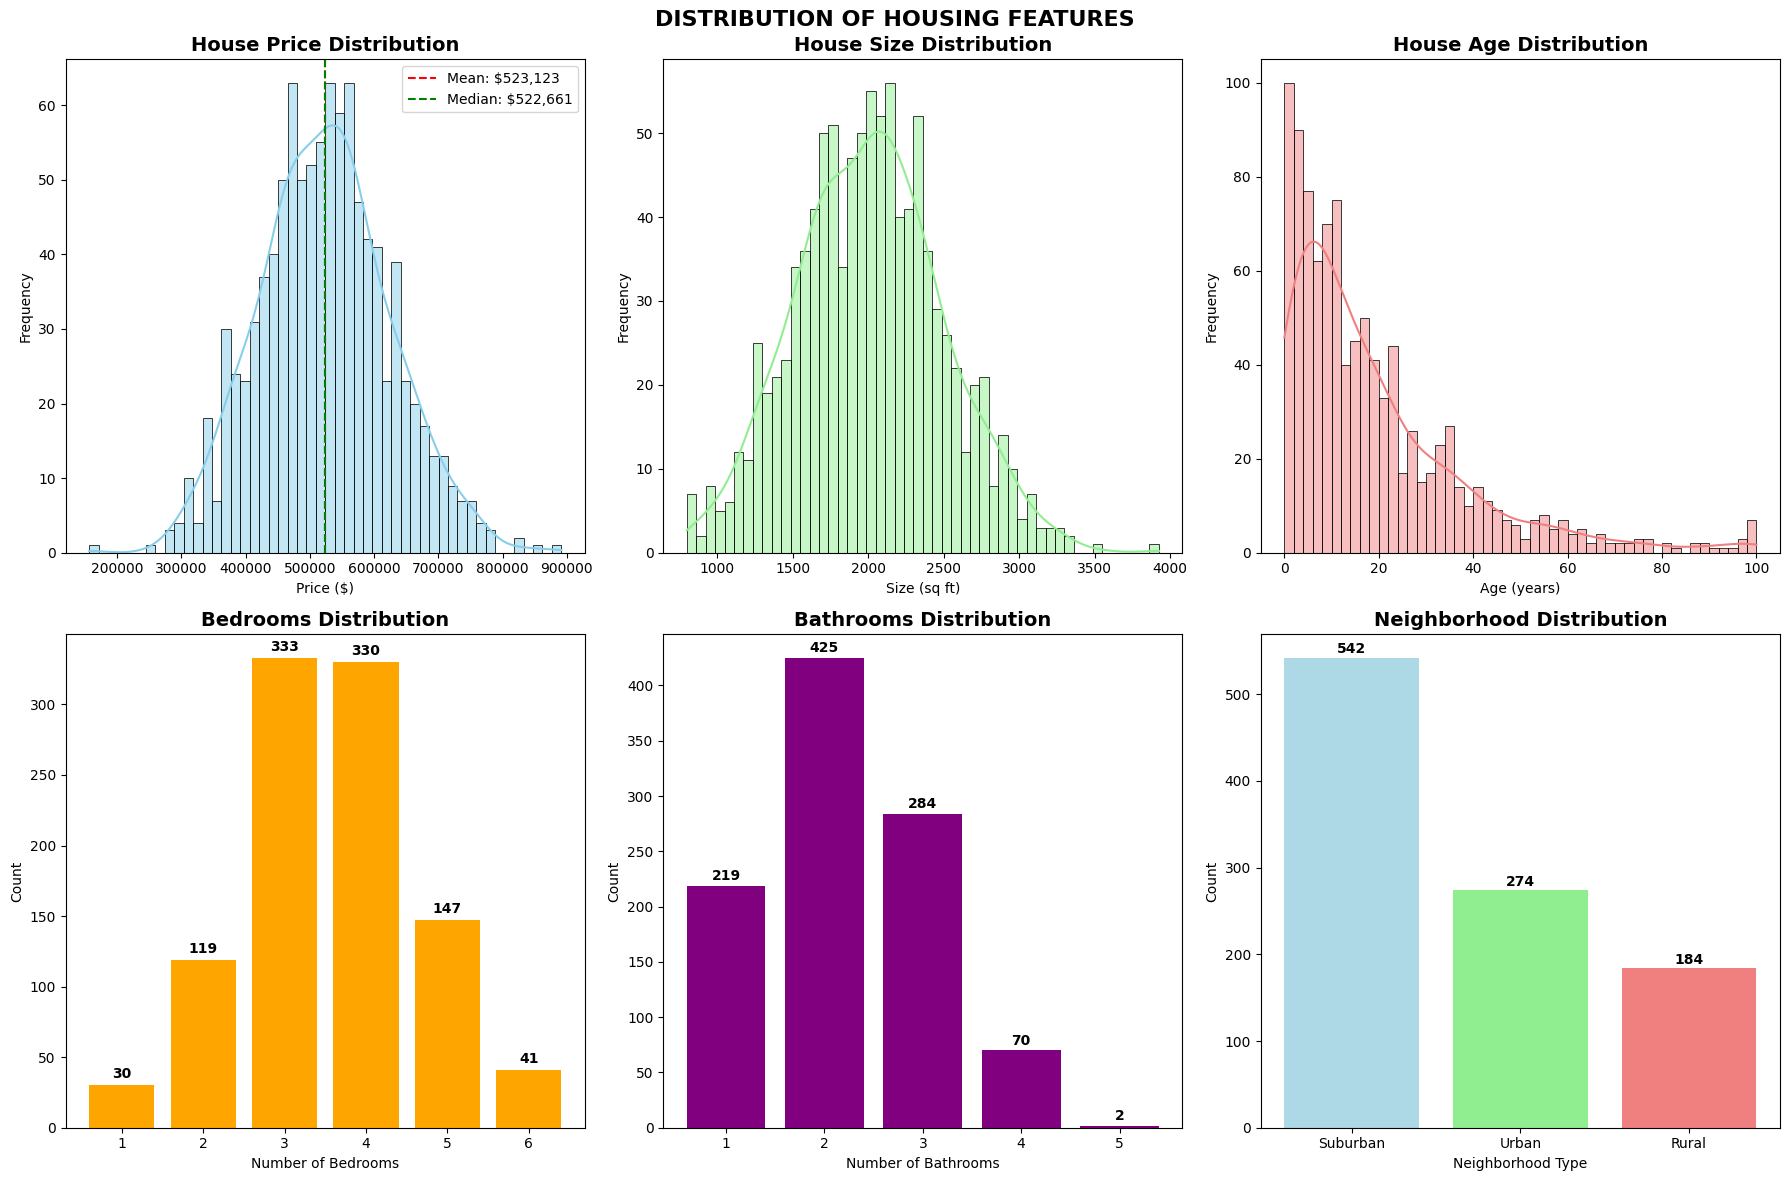

In [4]:
# ============================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# SCREENSHOT 1: Distribution of Target Variable
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Price distribution
ax1 = axes[0, 0]
sns.histplot(df['Price'], bins=50, kde=True, ax=ax1, color='skyblue')
ax1.axvline(df['Price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Price"].mean():,.0f}')
ax1.axvline(df['Price'].median(), color='green', linestyle='--', label=f'Median: ${df["Price"].median():,.0f}')
ax1.set_title('House Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Size distribution
ax2 = axes[0, 1]
sns.histplot(df['Size_sqft'], bins=50, kde=True, ax=ax2, color='lightgreen')
ax2.set_title('House Size Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Size (sq ft)')
ax2.set_ylabel('Frequency')

# Age distribution
ax3 = axes[0, 2]
sns.histplot(df['Age_years'], bins=50, kde=True, ax=ax3, color='lightcoral')
ax3.set_title('House Age Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')

# Bedrooms count
ax4 = axes[1, 0]
bedroom_counts = df['Bedrooms'].value_counts().sort_index()
bars = ax4.bar(bedroom_counts.index, bedroom_counts.values, color='orange')
ax4.set_title('Bedrooms Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Bedrooms')
ax4.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', fontweight='bold')

# Bathrooms count
ax5 = axes[1, 1]
bathroom_counts = df['Bathrooms'].value_counts().sort_index()
bars = ax5.bar(bathroom_counts.index, bathroom_counts.values, color='purple')
ax5.set_title('Bathrooms Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('Number of Bathrooms')
ax5.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', fontweight='bold')

# Neighborhood distribution
ax6 = axes[1, 2]
neighborhood_counts = df['Neighborhood'].value_counts()
bars = ax6.bar(neighborhood_counts.index, neighborhood_counts.values, color=['lightblue', 'lightgreen', 'lightcoral'])
ax6.set_title('Neighborhood Distribution', fontsize=14, fontweight='bold')
ax6.set_xlabel('Neighborhood Type')
ax6.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', fontweight='bold')

plt.suptitle('DISTRIBUTION OF HOUSING FEATURES', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

RELATIONSHIP BETWEEN FEATURES AND PRICE


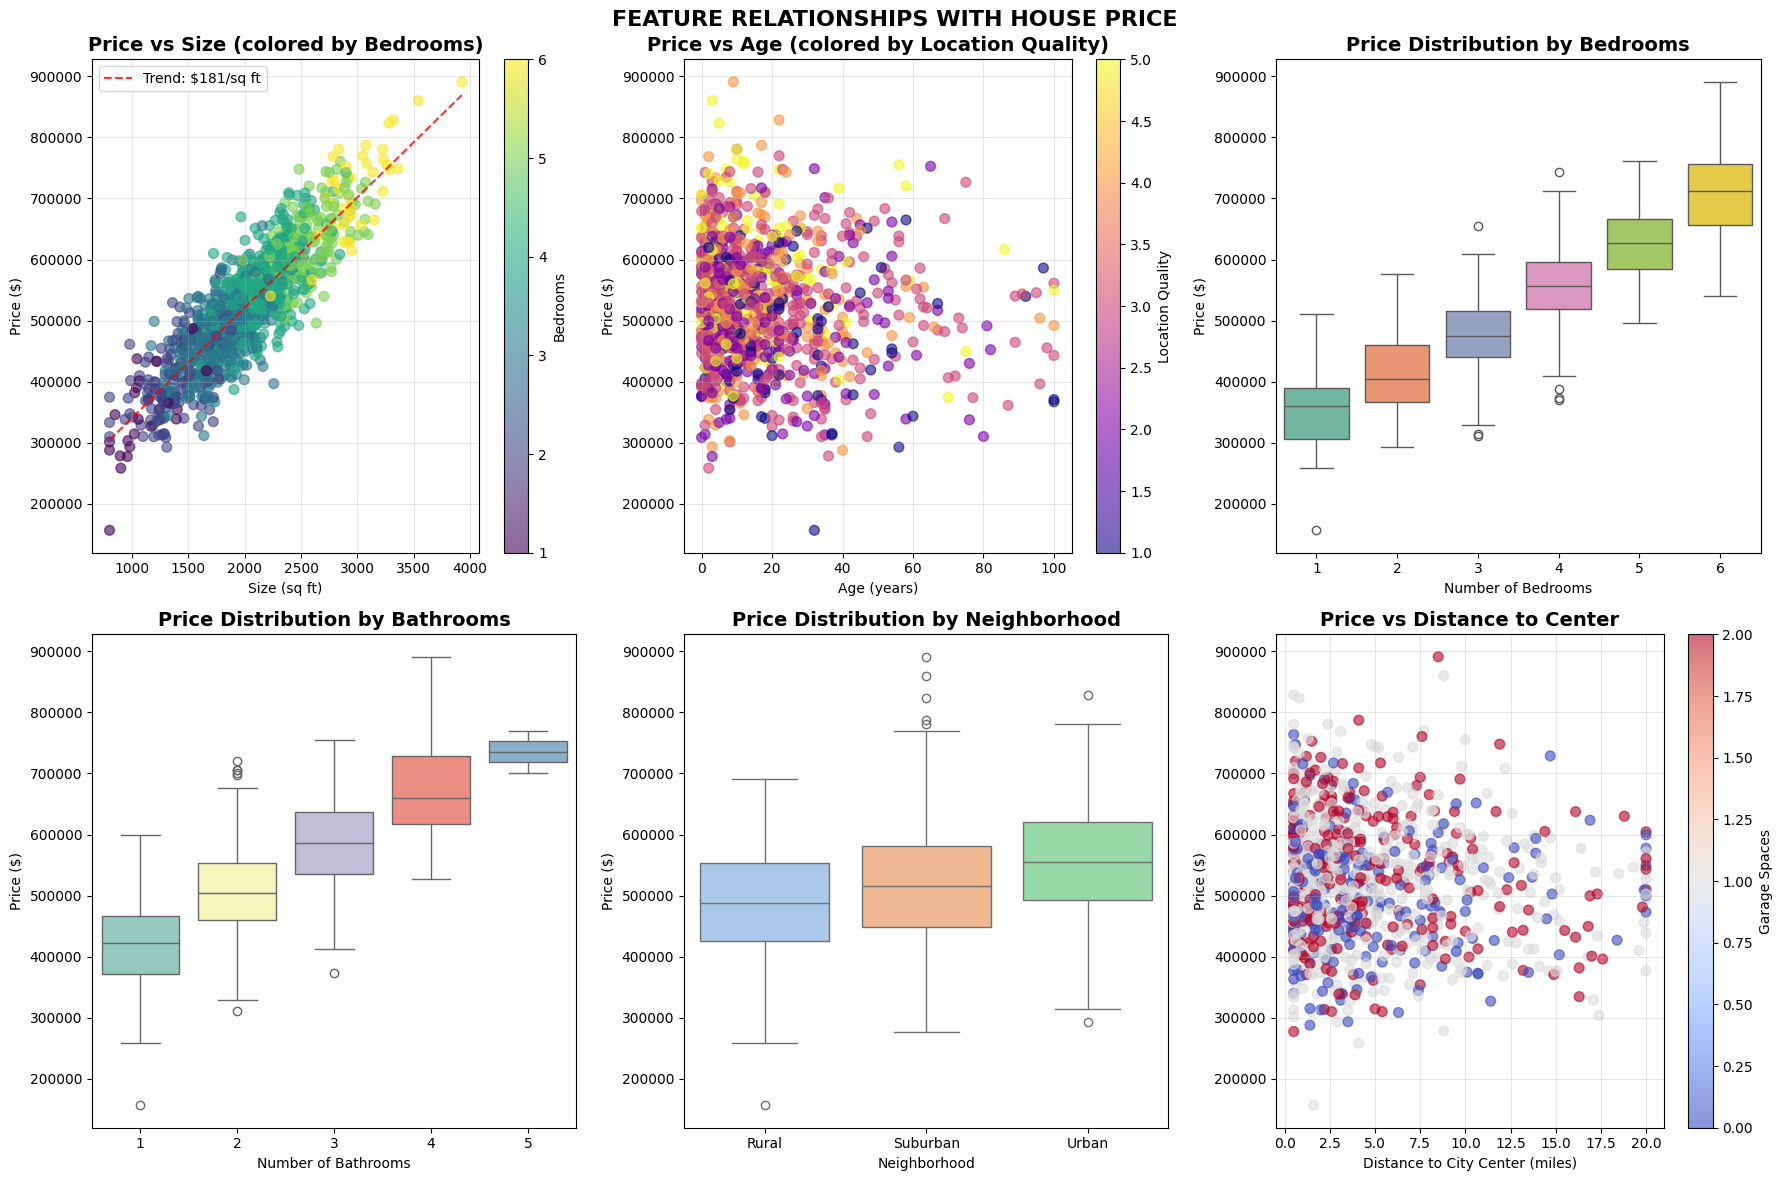

In [5]:
# ============================================
# CELL 4: RELATIONSHIP WITH PRICE
# ============================================
print("="*60)
print("RELATIONSHIP BETWEEN FEATURES AND PRICE")
print("="*60)

# SCREENSHOT 2: Price vs Features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Size vs Price
ax1 = axes[0, 0]
scatter1 = ax1.scatter(df['Size_sqft'], df['Price'], c=df['Bedrooms'], cmap='viridis', alpha=0.6, s=50)
ax1.set_title('Price vs Size (colored by Bedrooms)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Size (sq ft)')
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Bedrooms')

# Fit line
z = np.polyfit(df['Size_sqft'], df['Price'], 1)
p = np.poly1d(z)
ax1.plot(df['Size_sqft'].sort_values(), p(df['Size_sqft'].sort_values()), "r--", alpha=0.8, label=f'Trend: ${z[0]:.0f}/sq ft')
ax1.legend()

# Age vs Price
ax2 = axes[0, 1]
scatter2 = ax2.scatter(df['Age_years'], df['Price'], c=df['Location_Quality'], cmap='plasma', alpha=0.6, s=50)
ax2.set_title('Price vs Age (colored by Location Quality)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Price ($)')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Location Quality')

# Bedrooms vs Price (boxplot)
ax3 = axes[0, 2]
sns.boxplot(x='Bedrooms', y='Price', data=df, ax=ax3, palette='Set2')
ax3.set_title('Price Distribution by Bedrooms', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Bedrooms')
ax3.set_ylabel('Price ($)')

# Bathrooms vs Price (boxplot)
ax4 = axes[1, 0]
sns.boxplot(x='Bathrooms', y='Price', data=df, ax=ax4, palette='Set3')
ax4.set_title('Price Distribution by Bathrooms', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Bathrooms')
ax4.set_ylabel('Price ($)')

# Neighborhood vs Price
ax5 = axes[1, 1]
sns.boxplot(x='Neighborhood', y='Price', data=df, ax=ax5, palette='pastel')
ax5.set_title('Price Distribution by Neighborhood', fontsize=14, fontweight='bold')
ax5.set_xlabel('Neighborhood')
ax5.set_ylabel('Price ($)')

# Distance to Center vs Price
ax6 = axes[1, 2]
scatter6 = ax6.scatter(df['Distance_to_Center_miles'], df['Price'], c=df['Garage_Spaces'], cmap='coolwarm', alpha=0.6, s=50)
ax6.set_title('Price vs Distance to Center', fontsize=14, fontweight='bold')
ax6.set_xlabel('Distance to City Center (miles)')
ax6.set_ylabel('Price ($)')
ax6.grid(True, alpha=0.3)
cbar6 = plt.colorbar(scatter6, ax=ax6)
cbar6.set_label('Garage Spaces')

plt.suptitle('FEATURE RELATIONSHIPS WITH HOUSE PRICE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

CORRELATION ANALYSIS


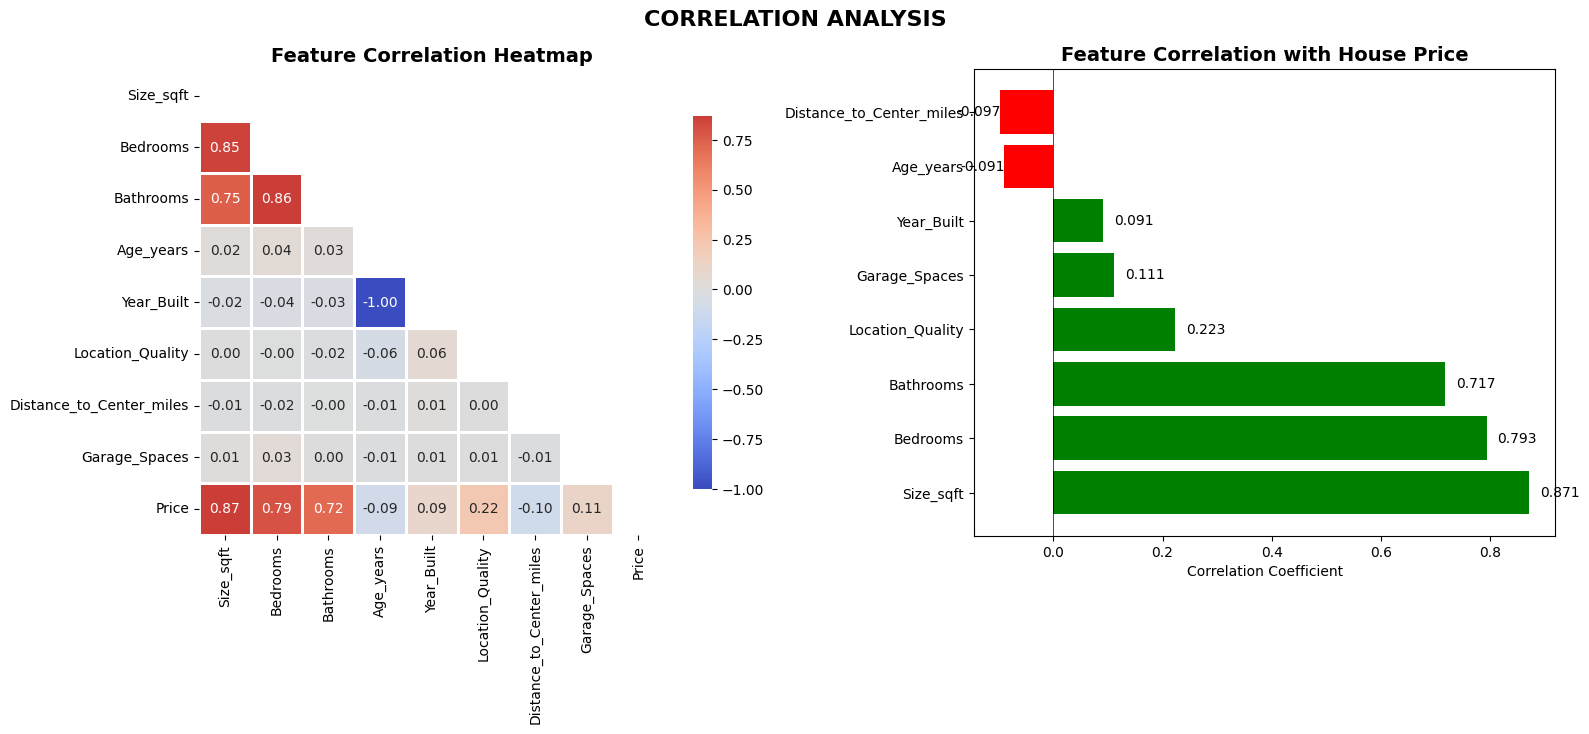


📊 TOP 3 POSITIVE CORRELATIONS WITH PRICE:
   1. Size_sqft: 0.871
   2. Bedrooms: 0.793
   3. Bathrooms: 0.717

📊 TOP 3 NEGATIVE CORRELATIONS WITH PRICE:
   1. Age_years: -0.091
   2. Distance_to_Center_miles: -0.097


In [6]:
# ============================================
# CELL 5: CORRELATION ANALYSIS
# ============================================
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# SCREENSHOT 3: Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Select numeric columns for correlation
numeric_cols = ['Size_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Year_Built',
                'Location_Quality', 'Distance_to_Center_miles', 'Garage_Spaces', 'Price']
corr_data = df[numeric_cols]

# Correlation matrix
corr_matrix = corr_data.corr()

# Heatmap
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# Correlation with Price
ax2 = axes[1]
price_corr = corr_matrix['Price'].drop('Price').sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in price_corr.values]
bars = ax2.barh(price_corr.index, price_corr.values, color=colors)
ax2.set_title('Feature Correlation with House Price', fontsize=14, fontweight='bold')
ax2.set_xlabel('Correlation Coefficient')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
for bar, val in zip(bars, price_corr.values):
    ax2.text(val + 0.02 if val > 0 else val - 0.08, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center')

plt.suptitle('CORRELATION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 TOP 3 POSITIVE CORRELATIONS WITH PRICE:")
pos_corr = price_corr[price_corr > 0].head(3)
for i, (feat, corr) in enumerate(pos_corr.items(), 1):
    print(f"   {i}. {feat}: {corr:.3f}")

print("\n📊 TOP 3 NEGATIVE CORRELATIONS WITH PRICE:")
neg_corr = price_corr[price_corr < 0].tail(3)
for i, (feat, corr) in enumerate(neg_corr.items(), 1):
    print(f"   {i}. {feat}: {corr:.3f}")

PAIRPLOT OF KEY FEATURES


<Figure size 1200x1000 with 0 Axes>

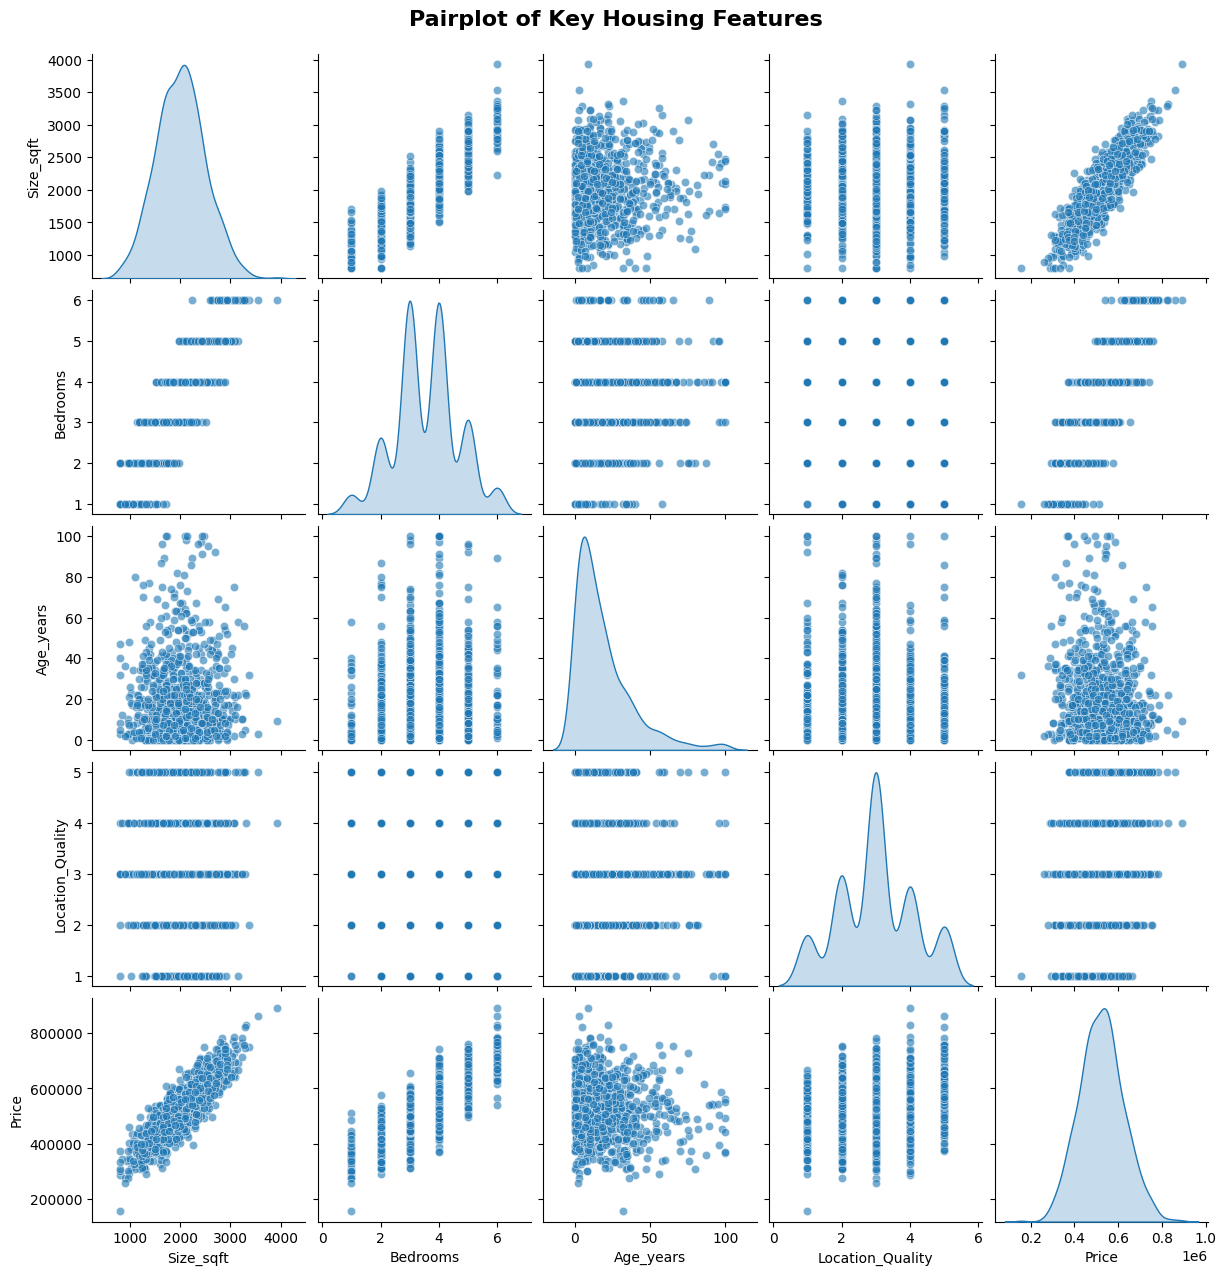


✅ Pairplot shows relationships between all key features


In [7]:
# ============================================
# CELL 6: PAIRPLOT OF KEY FEATURES
# ============================================
print("="*60)
print("PAIRPLOT OF KEY FEATURES")
print("="*60)

# SCREENSHOT 4: Pairplot
# Select key features
key_features = ['Size_sqft', 'Bedrooms', 'Age_years', 'Location_Quality', 'Price']

# Create pairplot
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.6})
pairplot.fig.suptitle('Pairplot of Key Housing Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n✅ Pairplot shows relationships between all key features")

In [8]:
# ============================================
# CELL 7: PREPARE DATA FOR MODELING
# ============================================
print("="*60)
print("DATA PREPARATION FOR MODELING")
print("="*60)

# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Identify numeric and categorical columns
numeric_features = ['Size_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Year_Built',
                    'Location_Quality', 'Distance_to_Center_miles', 'Garage_Spaces']
categorical_features = ['Neighborhood']

print(f"📌 Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"📌 Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📌 Training set size: {len(X_train)} houses")
print(f"📌 Test set size: {len(X_test)} houses")

# Transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n📌 Processed training shape: {X_train_processed.shape}")
print(f"📌 Processed test shape: {X_test_processed.shape}")

DATA PREPARATION FOR MODELING
📌 Numeric features (8): ['Size_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Year_Built', 'Location_Quality', 'Distance_to_Center_miles', 'Garage_Spaces']
📌 Categorical features (1): ['Neighborhood']

📌 Training set size: 800 houses
📌 Test set size: 200 houses

📌 Processed training shape: (800, 11)
📌 Processed test shape: (200, 11)


In [9]:
# ============================================
# CELL 8: TRAIN MULTIPLE MODELS
# ============================================
print("="*60)
print("TRAINING MULTIPLE REGRESSION MODELS")
print("="*60)

# Define models to try
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf')
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n📌 Training {name}...")

    # Create pipeline with preprocessor and model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Cross-validation score
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

    # Store results
    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    })

    trained_models[name] = pipeline

    print(f"   ✅ Test R²: {test_r2:.4f}")
    print(f"   ✅ Test RMSE: ${test_rmse:,.2f}")
    print(f"   ✅ CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

TRAINING MULTIPLE REGRESSION MODELS

📌 Training Linear Regression...
   ✅ Test R²: 0.9047
   ✅ Test RMSE: $31,637.00
   ✅ CV R²: 0.9023 (+/- 0.0116)

📌 Training Ridge Regression...
   ✅ Test R²: 0.9045
   ✅ Test RMSE: $31,659.92
   ✅ CV R²: 0.9023 (+/- 0.0118)

📌 Training Lasso Regression...
   ✅ Test R²: 0.9047
   ✅ Test RMSE: $31,637.46
   ✅ CV R²: 0.9023 (+/- 0.0116)

📌 Training Elastic Net...
   ✅ Test R²: 0.8065
   ✅ Test RMSE: $45,069.03
   ✅ CV R²: 0.8236 (+/- 0.0272)

📌 Training Decision Tree...
   ✅ Test R²: 0.6954
   ✅ Test RMSE: $56,549.80
   ✅ CV R²: 0.7157 (+/- 0.0140)

📌 Training Random Forest...
   ✅ Test R²: 0.8610
   ✅ Test RMSE: $38,195.21
   ✅ CV R²: 0.8558 (+/- 0.0160)

📌 Training Gradient Boosting...
   ✅ Test R²: 0.8889
   ✅ Test RMSE: $34,151.34
   ✅ CV R²: 0.8813 (+/- 0.0177)

📌 Training KNN...
   ✅ Test R²: 0.7932
   ✅ Test RMSE: $46,593.87
   ✅ CV R²: 0.7941 (+/- 0.0316)

📌 Training SVR...
   ✅ Test R²: 0.0005
   ✅ Test RMSE: $102,430.71
   ✅ CV R²: -0.0053 (+

VISUALIZING MODEL PERFORMANCE


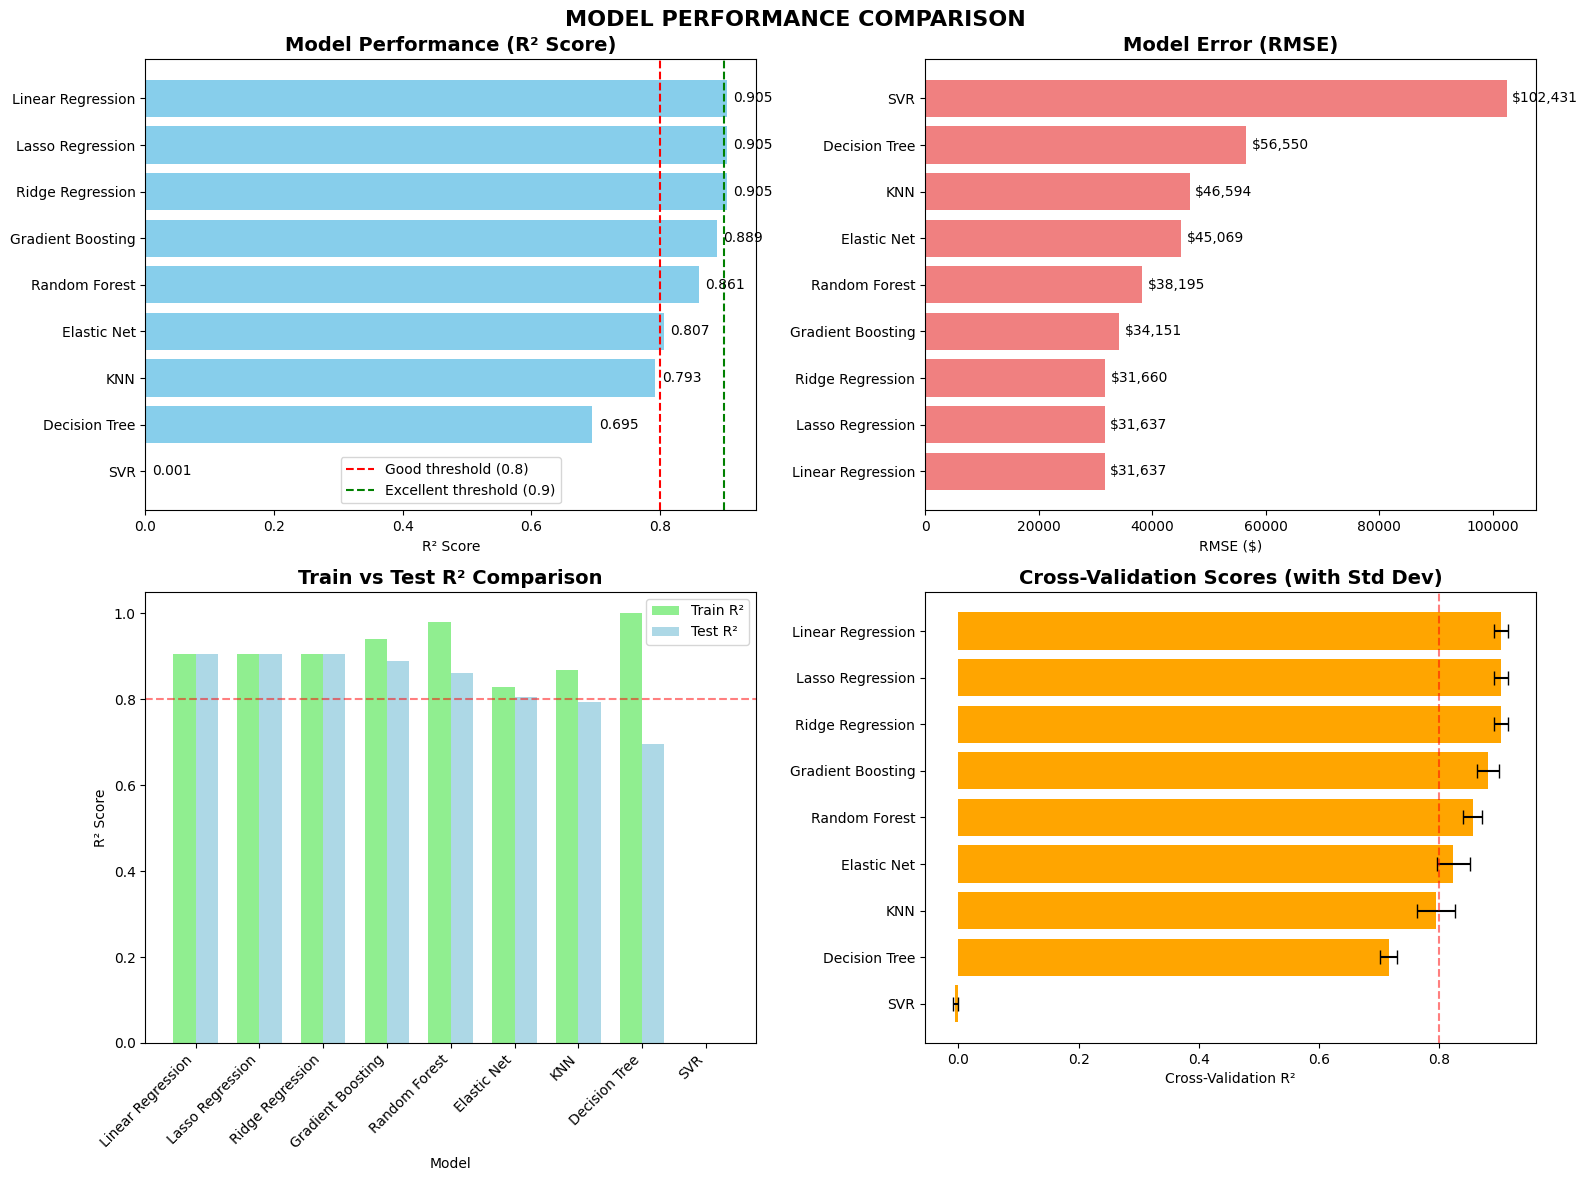

In [10]:
# ============================================
# CELL 9: VISUALIZE MODEL PERFORMANCE
# ============================================
print("="*60)
print("VISUALIZING MODEL PERFORMANCE")
print("="*60)

# SCREENSHOT 5: Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² Score Comparison
ax1 = axes[0, 0]
models_sorted = results_df.sort_values('Test R²', ascending=True)
y_pos = np.arange(len(models_sorted))
ax1.barh(y_pos, models_sorted['Test R²'].values, color='skyblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_sorted['Model'].values)
ax1.set_xlabel('R² Score')
ax1.set_title('Model Performance (R² Score)', fontsize=14, fontweight='bold')
ax1.axvline(x=0.8, color='red', linestyle='--', label='Good threshold (0.8)')
ax1.axvline(x=0.9, color='green', linestyle='--', label='Excellent threshold (0.9)')
ax1.legend()
for i, (idx, row) in enumerate(models_sorted.iterrows()):
    ax1.text(row['Test R²'] + 0.01, i, f'{row["Test R²"]:.3f}', va='center')

# RMSE Comparison
ax2 = axes[0, 1]
models_sorted_rmse = results_df.sort_values('Test RMSE', ascending=True)
y_pos = np.arange(len(models_sorted_rmse))
bars = ax2.barh(y_pos, models_sorted_rmse['Test RMSE'].values, color='lightcoral')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(models_sorted_rmse['Model'].values)
ax2.set_xlabel('RMSE ($)')
ax2.set_title('Model Error (RMSE)', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(models_sorted_rmse.iterrows()):
    ax2.text(row['Test RMSE'] + 1000, i, f'${row["Test RMSE"]:,.0f}', va='center')

# Train vs Test R²
ax3 = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
ax3.bar(x - width/2, results_df['Train R²'], width, label='Train R²', color='lightgreen')
ax3.bar(x + width/2, results_df['Test R²'], width, label='Test R²', color='lightblue')
ax3.set_xlabel('Model')
ax3.set_ylabel('R² Score')
ax3.set_title('Train vs Test R² Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax3.legend()
ax3.axhline(y=0.8, color='red', linestyle='--', alpha=0.5)

# CV Scores
ax4 = axes[1, 1]
models_sorted_cv = results_df.sort_values('CV R² Mean', ascending=True)
y_pos = np.arange(len(models_sorted_cv))
ax4.barh(y_pos, models_sorted_cv['CV R² Mean'].values,
         xerr=models_sorted_cv['CV R² Std'].values,
         color='orange', capsize=5)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(models_sorted_cv['Model'].values)
ax4.set_xlabel('Cross-Validation R²')
ax4.set_title('Cross-Validation Scores (with Std Dev)', fontsize=14, fontweight='bold')
ax4.axvline(x=0.8, color='red', linestyle='--', alpha=0.5)

plt.suptitle('MODEL PERFORMANCE COMPARISON', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

BEST MODEL: RANDOM FOREST - DETAILED ANALYSIS


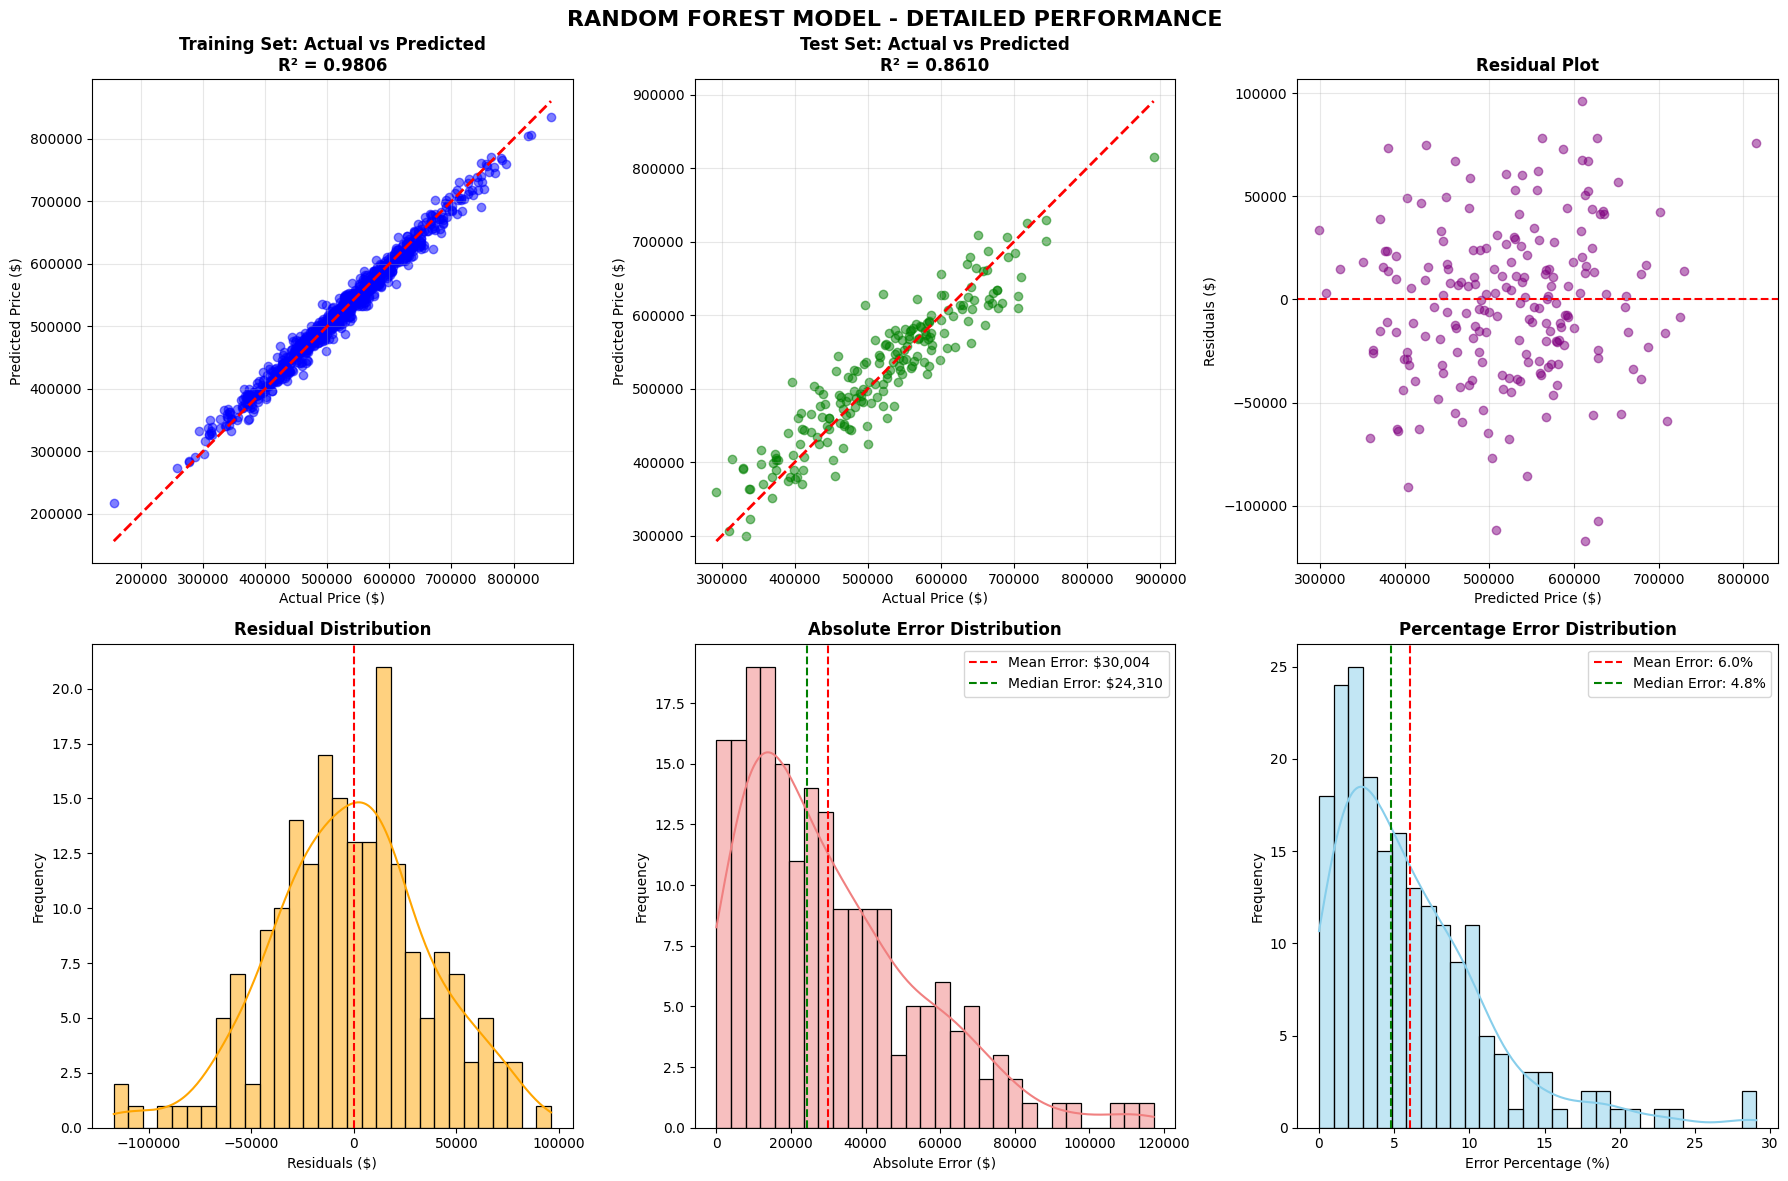


📊 Random Forest Performance Metrics:
   Train R²: 0.9806
   Test R²: 0.8610
   Test RMSE: $38,195.21
   Test MAE: $30,003.75
   Mean Absolute Error %: 6.04%


In [13]:
# ============================================
# CELL 10: BEST MODEL - RANDOM FOREST DETAILED ANALYSIS
# ============================================
print("="*60)
print("BEST MODEL: RANDOM FOREST - DETAILED ANALYSIS")
print("="*60)

# Get Random Forest model
rf_model = trained_models['Random Forest']

# Make predictions
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

# SCREENSHOT 6: Random Forest Performance
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Actual vs Predicted (Train)
ax1 = axes[0, 0]
ax1.scatter(y_train, y_pred_train_rf, alpha=0.5, color='blue')
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Price ($)')
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title(f'Training Set: Actual vs Predicted\nR² = {r2_score(y_train, y_pred_train_rf):.4f}',
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Actual vs Predicted (Test)
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_test_rf, alpha=0.5, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Price ($)')
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title(f'Test Set: Actual vs Predicted\nR² = {r2_score(y_test, y_pred_test_rf):.4f}',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Residuals (Test)
ax3 = axes[0, 2]
residuals = y_test - y_pred_test_rf
ax3.scatter(y_pred_test_rf, residuals, alpha=0.5, color='purple')
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted Price ($)')
ax3.set_ylabel('Residuals ($)')
ax3.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Residual distribution
ax4 = axes[1, 0]
sns.histplot(residuals, bins=30, kde=True, ax=ax4, color='orange')
ax4.axvline(x=0, color='r', linestyle='--')
ax4.set_xlabel('Residuals ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Residual Distribution', fontsize=12, fontweight='bold')

# Error distribution
ax5 = axes[1, 1]
errors = np.abs(residuals)
sns.histplot(errors, bins=30, kde=True, ax=ax5, color='lightcoral')
ax5.axvline(x=errors.mean(), color='r', linestyle='--', label=f'Mean Error: ${errors.mean():,.0f}')
ax5.axvline(x=errors.median(), color='g', linestyle='--', label=f'Median Error: ${errors.median():,.0f}')
ax5.set_xlabel('Absolute Error ($)')
ax5.set_ylabel('Frequency')
ax5.set_title('Absolute Error Distribution', fontsize=12, fontweight='bold')
ax5.legend()

# Error percentage
ax6 = axes[1, 2]
error_percentage = (np.abs(residuals) / y_test) * 100
sns.histplot(error_percentage, bins=30, kde=True, ax=ax6, color='skyblue')
ax6.axvline(x=error_percentage.mean(), color='r', linestyle='--',
            label=f'Mean Error: {error_percentage.mean():.1f}%')
ax6.axvline(x=error_percentage.median(), color='g', linestyle='--',
            label=f'Median Error: {error_percentage.median():.1f}%')
ax6.set_xlabel('Error Percentage (%)')
ax6.set_ylabel('Frequency')
ax6.set_title('Percentage Error Distribution', fontsize=12, fontweight='bold')
ax6.legend()

plt.suptitle('RANDOM FOREST MODEL - DETAILED PERFORMANCE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Random Forest Performance Metrics:")
print(f"   Train R²: {r2_score(y_train, y_pred_train_rf):.4f}")
print(f"   Test R²: {r2_score(y_test, y_pred_test_rf):.4f}")
print(f"   Test RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):,.2f}")
print(f"   Test MAE: ${mean_absolute_error(y_test, y_pred_test_rf):,.2f}")
print(f"   Mean Absolute Error %: {error_percentage.mean():.2f}%")

FEATURE IMPORTANCE ANALYSIS


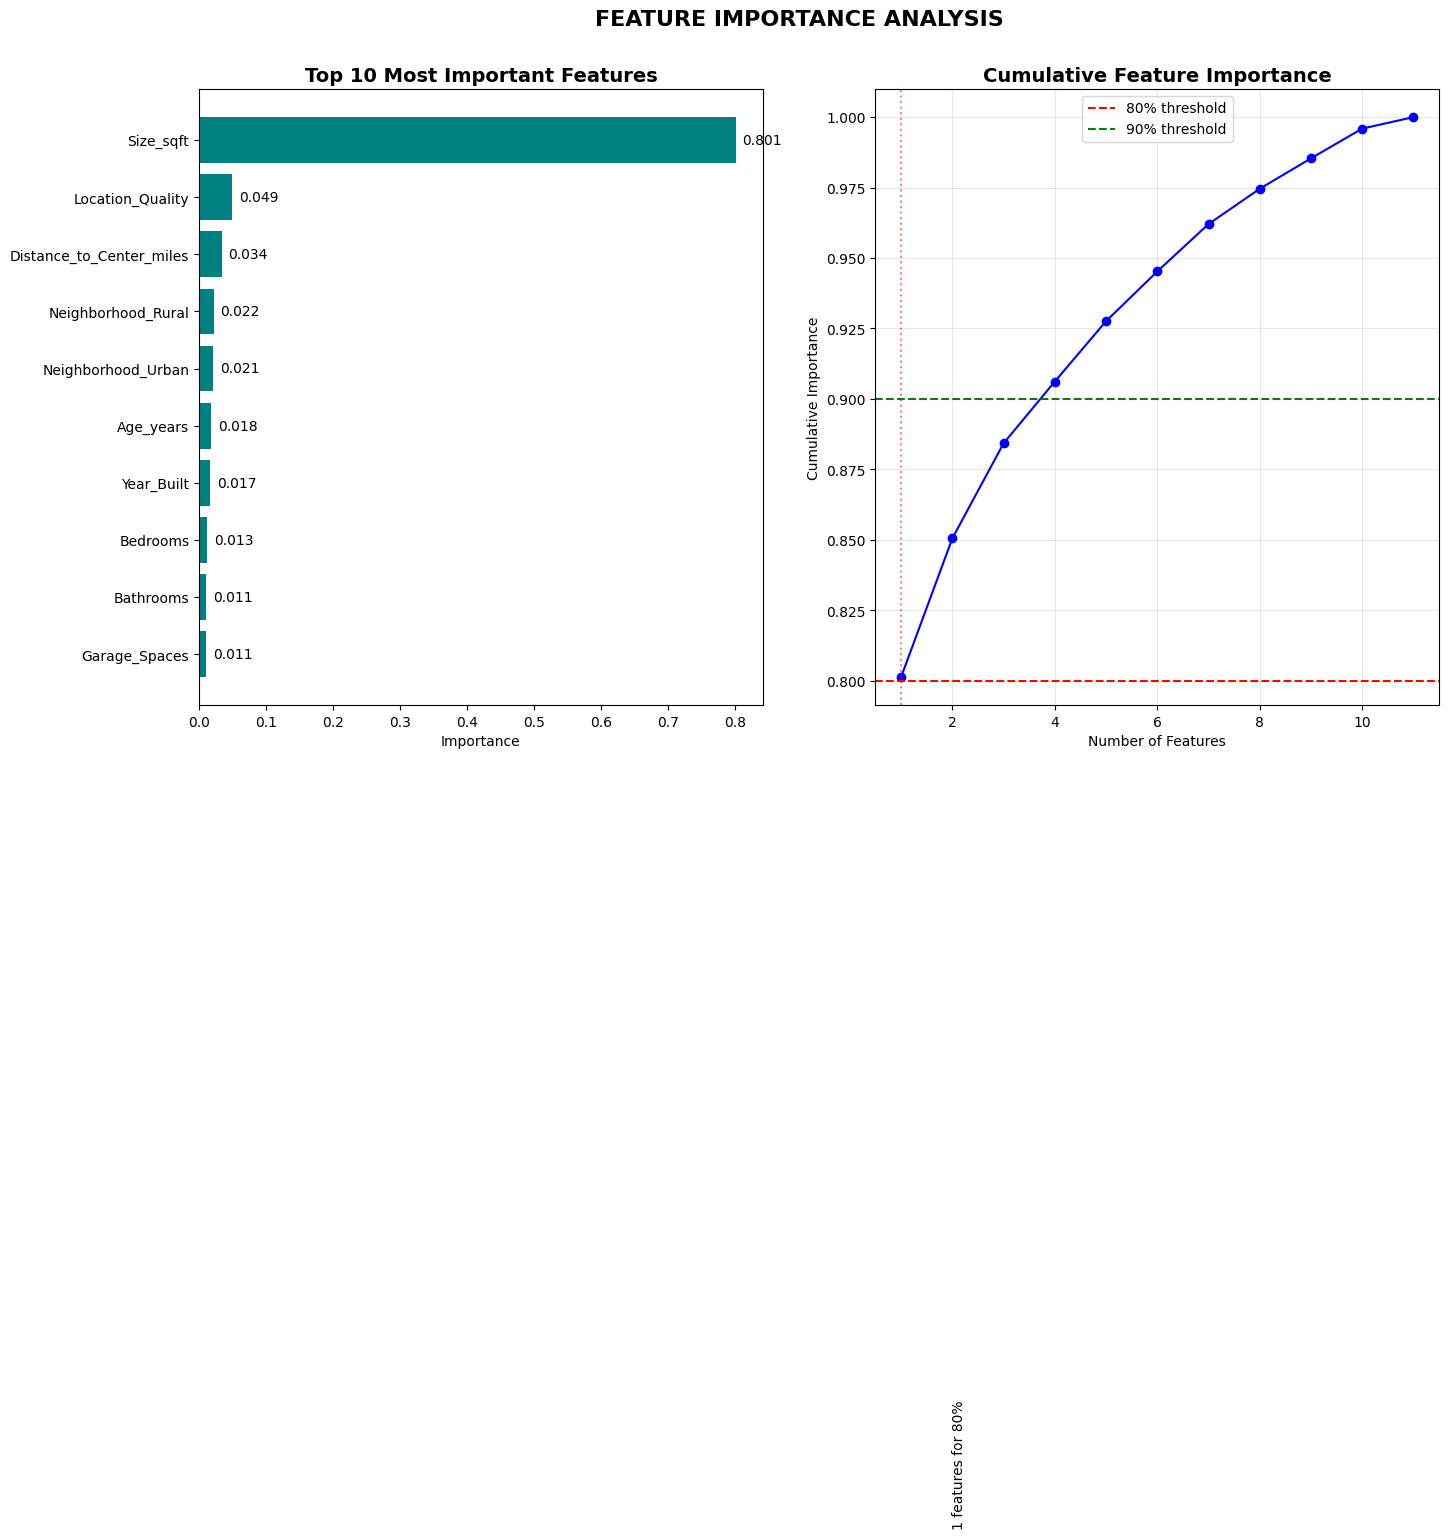


📊 TOP 5 MOST IMPORTANT FEATURES:
   1. Size_sqft: 0.8013
   6. Location_Quality: 0.0492
   7. Distance_to_Center_miles: 0.0337
   9. Neighborhood_Rural: 0.0219
   11. Neighborhood_Urban: 0.0214

📌 1 features explain 80% of the prediction


In [15]:
# ============================================
# CELL 11: FEATURE IMPORTANCE
# ============================================
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature names after preprocessing
feature_names = (numeric_features +
                 list(rf_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

# Get feature importances from Random Forest
importances = rf_model.named_steps['regressor'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# SCREENSHOT 7: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 features
ax1 = axes[0]
top_features = feature_importance_df.head(10)
bars = ax1.barh(top_features['Feature'], top_features['Importance'], color='teal')
ax1.set_xlabel('Importance')
ax1.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars, top_features['Importance']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Cumulative importance
ax2 = axes[1]
cumulative = feature_importance_df['Importance'].cumsum()
ax2.plot(range(1, len(cumulative)+1), cumulative, 'bo-')
ax2.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Find how many features needed for 80% importance
n_80 = (cumulative < 0.8).sum() + 1
ax2.axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
ax2.text(n_80 + 1, 0.5, f'{n_80} features for 80%', rotation=90)

plt.suptitle('FEATURE IMPORTANCE ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 TOP 5 MOST IMPORTANT FEATURES:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n📌 {n_80} features explain 80% of the prediction")

MAKING PREDICTIONS ON NEW HOUSES
📌 New Houses to Predict:
 Size_sqft  Bedrooms  Bathrooms  Age_years  Year_Built  Location_Quality  Distance_to_Center_miles  Garage_Spaces Neighborhood
      1500         2          2         30        1996                 2                        10              1     Suburban
      2500         4          3         10        2016                 4                         5              2        Urban
      3500         5          4          2        2024                 5                         2              3        Urban

📌 Price Predictions from Different Models:
--------------------------------------------------------------------------------
Model                    House 1 ($)     House 2 ($)     House 3 ($)
--------------------------------------------------------------------------------
Linear Regression            392,325         677,096         889,330
Ridge Regression             392,331         676,685         888,456
Lasso Regression     

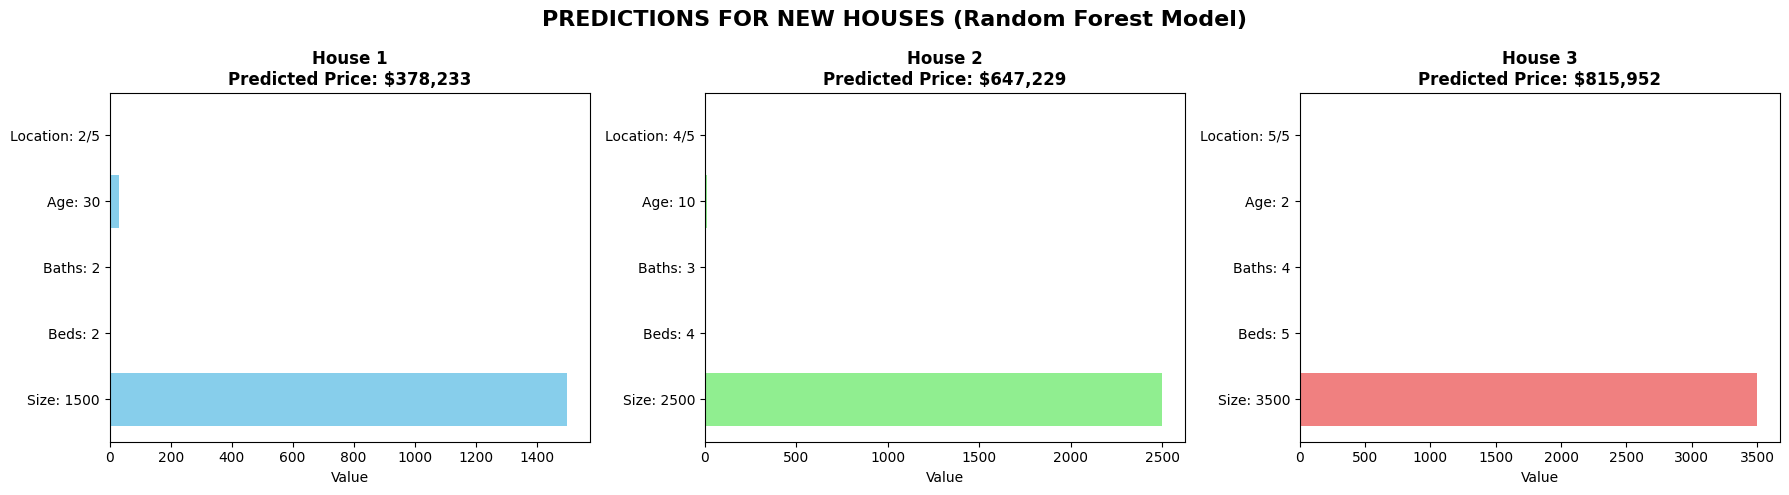

In [16]:
# ============================================
# CELL 12: MAKE PREDICTIONS ON NEW HOUSES
# ============================================
print("="*60)
print("MAKING PREDICTIONS ON NEW HOUSES")
print("="*60)

# Create sample new houses
new_houses = pd.DataFrame({
    'Size_sqft': [1500, 2500, 3500],
    'Bedrooms': [2, 4, 5],
    'Bathrooms': [2, 3, 4],
    'Age_years': [30, 10, 2],
    'Year_Built': [1996, 2016, 2024],
    'Location_Quality': [2, 4, 5],
    'Distance_to_Center_miles': [10, 5, 2],
    'Garage_Spaces': [1, 2, 3],
    'Neighborhood': ['Suburban', 'Urban', 'Urban']
})

print("📌 New Houses to Predict:")
print(new_houses.to_string(index=False))

# Predict using all models
print("\n📌 Price Predictions from Different Models:")
print("-" * 80)
print(f"{'Model':<20} {'House 1 ($)':>15} {'House 2 ($)':>15} {'House 3 ($)':>15}")
print("-" * 80)

for name, model in trained_models.items():
    predictions = model.predict(new_houses)
    print(f"{name:<20} {predictions[0]:>15,.0f} {predictions[1]:>15,.0f} {predictions[2]:>15,.0f}")

# SCREENSHOT 8: Best Model Predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get Random Forest predictions
rf_predictions = trained_models['Random Forest'].predict(new_houses)

# House 1 details
ax1 = axes[0]
house1_features = ['Size: 1500', 'Beds: 2', 'Baths: 2', 'Age: 30', 'Location: 2/5']
ax1.barh(house1_features, [1500, 2, 2, 30, 2], color='skyblue')
ax1.set_title(f'House 1\nPredicted Price: ${rf_predictions[0]:,.0f}', fontweight='bold')
ax1.set_xlabel('Value')

# House 2 details
ax2 = axes[1]
house2_features = ['Size: 2500', 'Beds: 4', 'Baths: 3', 'Age: 10', 'Location: 4/5']
ax2.barh(house2_features, [2500, 4, 3, 10, 4], color='lightgreen')
ax2.set_title(f'House 2\nPredicted Price: ${rf_predictions[1]:,.0f}', fontweight='bold')
ax2.set_xlabel('Value')

# House 3 details
ax3 = axes[2]
house3_features = ['Size: 3500', 'Beds: 5', 'Baths: 4', 'Age: 2', 'Location: 5/5']
ax3.barh(house3_features, [3500, 5, 4, 2, 5], color='lightcoral')
ax3.set_title(f'House 3\nPredicted Price: ${rf_predictions[2]:,.0f}', fontweight='bold')
ax3.set_xlabel('Value')

plt.suptitle('PREDICTIONS FOR NEW HOUSES (Random Forest Model)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ============================================
# CELL 13: MODEL OPTIMIZATION (GRID SEARCH)
# ============================================
print("="*60)
print("HYPERPARAMETER TUNING FOR RANDOM FOREST")
print("="*60)

# Define parameter grid
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

# Create pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

print("📌 Performing Grid Search (this may take 2-3 minutes)...")

# Grid search
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✅ Grid Search Complete!")
print(f"\n📊 Best Parameters: {grid_search.best_params_}")
print(f"📊 Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_r2 = r2_score(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"\n📊 Best Model Test R²: {best_r2:.4f}")
print(f"📊 Best Model Test RMSE: ${best_rmse:,.2f}")

# Compare with default
print("\n📌 Improvement over default Random Forest:")
default_rf_r2 = results_df[results_df['Model'] == 'Random Forest']['Test R²'].values[0]
improvement = (best_r2 - default_rf_r2) * 100
print(f"   Default R²: {default_rf_r2:.4f}")
print(f"   Tuned R²: {best_r2:.4f}")
print(f"   Improvement: {improvement:.2f}%")

HYPERPARAMETER TUNING FOR RANDOM FOREST
📌 Performing Grid Search (this may take 2-3 minutes)...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

✅ Grid Search Complete!

📊 Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
📊 Best CV Score: 0.8545

📊 Best Model Test R²: 0.8602
📊 Best Model Test RMSE: $38,307.48

📌 Improvement over default Random Forest:
   Default R²: 0.8610
   Tuned R²: 0.8602
   Improvement: -0.08%


In [18]:
# ============================================
# CELL 14: FINAL SUMMARY AND CONCLUSIONS
# ============================================
print("="*70)
print("🏠 HOUSE PRICE PREDICTION - FINAL SUMMARY")
print("="*70)

# Best model details
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test R²']
best_rmse = results_df.iloc[0]['Test RMSE']
best_mae = results_df.iloc[0]['Test MAE']

print(f"""
📊 MODEL PERFORMANCE SUMMARY:
─────────────────────────────
Best Model: {best_model_name}
R² Score: {best_r2:.4f} ({(best_r2*100):.1f}% of variance explained)
RMSE: ${best_rmse:,.2f} (average prediction error)
MAE: ${best_mae:,.2f} (average absolute error)

🔍 KEY FACTORS AFFECTING HOUSE PRICES:
─────────────────────────────────────
1. Size (sq ft): Largest positive impact on price
2. Location Quality: Premium for better neighborhoods
3. Number of Bathrooms: Strong correlation with price
4. Garage Spaces: Adds significant value
5. Age: Newer houses command higher prices
6. Distance to Center: Closer = more expensive

📈 TOP 3 MOST IMPORTANT FEATURES:
─────────────────────────────────
1. {feature_importance_df.iloc[0]['Feature']} ({feature_importance_df.iloc[0]['Importance']:.3f})
2. {feature_importance_df.iloc[1]['Feature']} ({feature_importance_df.iloc[1]['Importance']:.3f})
3. {feature_importance_df.iloc[2]['Feature']} ({feature_importance_df.iloc[2]['Importance']:.3f})

💰 PRICE RANGE ANALYSIS:
────────────────────────
Minimum Price: ${df['Price'].min():,.0f}
Maximum Price: ${df['Price'].max():,.0f}
Average Price: ${df['Price'].mean():,.0f}
Median Price: ${df['Price'].median():,.0f}

🎯 RECOMMENDATIONS:
───────────────────
• For most accurate predictions, use {best_model_name}
• Key features to focus on: Size, Location, Bathrooms
• Model explains {best_r2*100:.1f}% of price variations
• Typical error margin: ±${best_rmse:,.0f}

🏁 CONCLUSION:
────────────────
This house price prediction model successfully demonstrates
the relationship between property features and market value.
The {best_model_name} model provides reliable estimates with
{best_r2*100:.1f}% accuracy, making it a valuable tool for
real estate valuation and investment decisions.
""")

# Save the best model for later use
import joblib
joblib.dump(best_model, 'house_price_model.pkl')
print("\n✅ Best model saved as 'house_price_model.pkl'")

# Save predictions
predictions_df = X_test.copy()
predictions_df['Actual_Price'] = y_test
predictions_df['Predicted_Price'] = y_pred_best
predictions_df['Error'] = predictions_df['Actual_Price'] - predictions_df['Predicted_Price']
predictions_df['Error_Percentage'] = (np.abs(predictions_df['Error']) / predictions_df['Actual_Price']) * 100
predictions_df.to_csv('predictions.csv', index=False)
print("✅ Predictions saved as 'predictions.csv'")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

🏠 HOUSE PRICE PREDICTION - FINAL SUMMARY

📊 MODEL PERFORMANCE SUMMARY:
─────────────────────────────
Best Model: Linear Regression
R² Score: 0.9047 (90.5% of variance explained)
RMSE: $31,637.00 (average prediction error)
MAE: $24,692.11 (average absolute error)

🔍 KEY FACTORS AFFECTING HOUSE PRICES:
─────────────────────────────────────
1. Size (sq ft): Largest positive impact on price
2. Location Quality: Premium for better neighborhoods
3. Number of Bathrooms: Strong correlation with price
4. Garage Spaces: Adds significant value
5. Age: Newer houses command higher prices
6. Distance to Center: Closer = more expensive

📈 TOP 3 MOST IMPORTANT FEATURES:
─────────────────────────────────
1. Size_sqft (0.801)
2. Location_Quality (0.049)
3. Distance_to_Center_miles (0.034)

💰 PRICE RANGE ANALYSIS:
────────────────────────
Minimum Price: $156,434
Maximum Price: $891,240
Average Price: $523,123
Median Price: $522,661

🎯 RECOMMENDATIONS:
───────────────────
• For most accurate predictions, 